In [ ]:
# Task 4: Data Storytelling & Statistical Validation

## Superstore Sales Analysis

### Objective
To analyze sales and profit trends, identify business opportunities, and validate key findings using statistical testing.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [2]:
df = pd.read_csv("dataset/Sample - Superstore.csv", encoding="latin1")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
## Dataset Overview

The Superstore dataset contains information about:

- Orders
- Customers
- Products
- Sales
- Profit
- Discounts
- Regions

The goal is to identify patterns that influence business performance.

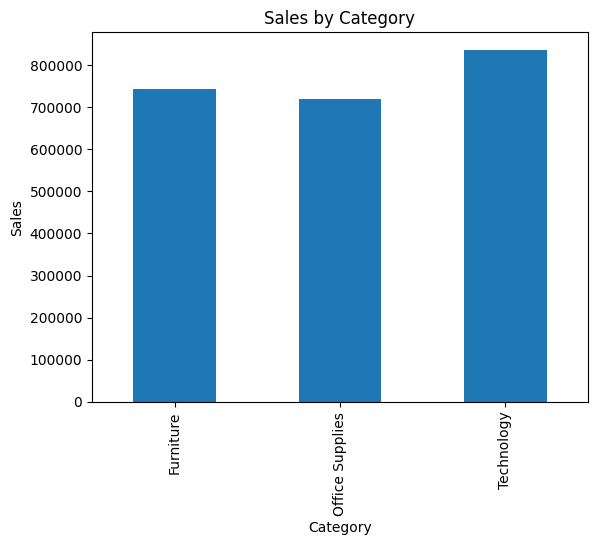

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [4]:
sales_by_category = df.groupby("Category")["Sales"].sum()

sales_by_category.plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

sales_by_category

In [ ]:
## Key Finding 1

Technology category generated the highest sales revenue.

This indicates strong customer demand and growth potential in technology products.

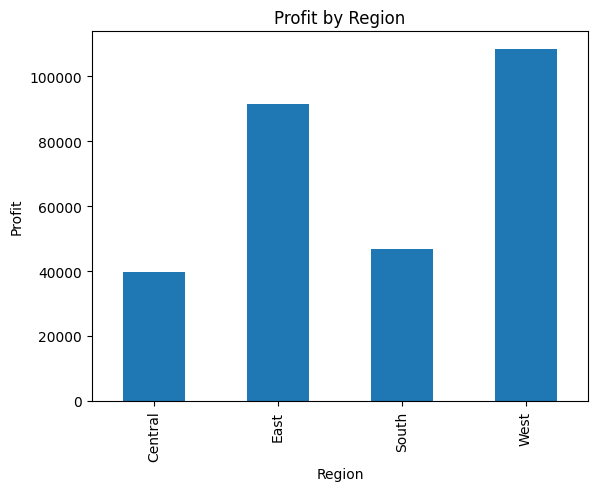

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

In [5]:
profit_by_region = df.groupby("Region")["Profit"].sum()

profit_by_region.plot(kind="bar")
plt.title("Profit by Region")
plt.ylabel("Profit")
plt.show()

profit_by_region

In [ ]:
## Key Finding 2

Certain regions contribute significantly more profit than others.

Business strategies should focus on high-performing regions while improving low-performing areas.

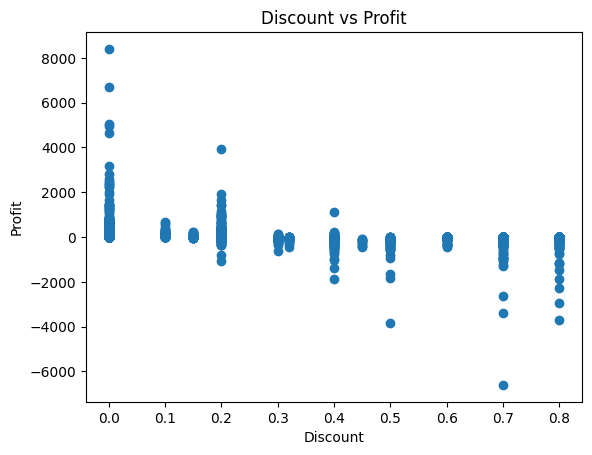

In [6]:
plt.scatter(df["Discount"], df["Profit"])

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")

plt.show()

In [ ]:
## Key Finding 3

As discounts increase, profitability tends to decrease.

Large discounts may boost sales volume but can negatively impact overall profit.

In [ ]:
# Statistical Validation

### Hypothesis

H₀: Discount has no significant relationship with Profit.

H₁: Discount has a significant relationship with Profit.

In [7]:
correlation, p_value = pearsonr(df["Discount"], df["Profit"])

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: -0.21948745637176847
P-value: 2.7022944361957867e-109


In [8]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Discount significantly impacts Profit")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis
Discount significantly impacts Profit
